In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import os
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../reports/figures', exist_ok=True)
print('Imports successful')

Imports successful


In [15]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

model = joblib.load('../models/xgboost.pkl')

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)  

n_customers   = len(y_test)
n_churners    = y_test.sum()
churn_rate    = y_test.mean()

print(f'Test set: {n_customers} customers')
print(f'Actual churners: {n_churners} ({churn_rate:.1%})')
print(f'Actual non-churners: {n_customers - n_churners}')

Test set: 1407 customers
Actual churners: 374 (26.6%)
Actual non-churners: 1033


In [16]:
#assumptions:
MONTHLY_CHARGE    = 64         
ANNUAL_REVENUE    = MONTHLY_CHARGE * 12   
OFFER_COST        = 80          
RETENTION_RATE    = 0.30        

COST_FN = ANNUAL_REVENUE               
COST_FP = OFFER_COST                   
COST_TP = OFFER_COST - (ANNUAL_REVENUE * RETENTION_RATE)  
COST_TN = 0                            

print('Cost Matrix:')
print(f'  True Positive  (correctly flagged churner): €{COST_TP:.0f}  '
      f'(offer costs €{OFFER_COST}, saves {RETENTION_RATE:.0%} × €{ANNUAL_REVENUE} = €{ANNUAL_REVENUE*RETENTION_RATE:.0f})')
print(f'  False Positive (false alarm):               €{COST_FP:.0f}  (wasted offer)')
print(f'  False Negative (missed churner):            €{COST_FN:.0f}  (lost annual revenue)')
print(f'  True Negative  (correct stay):              €{COST_TN:.0f}  (no action)')
print()
print(f'Annual revenue per customer: €{ANNUAL_REVENUE}')

Cost Matrix:
  True Positive  (correctly flagged churner): €-150  (offer costs €80, saves 30% × €768 = €230)
  False Positive (false alarm):               €80  (wasted offer)
  False Negative (missed churner):            €768  (lost annual revenue)
  True Negative  (correct stay):              €0  (no action)

Annual revenue per customer: €768


In [17]:
baseline_do_nothing = int(n_churners) * COST_FN

baseline_flag_all = (int(n_churners) * COST_TP) + (int(n_customers - n_churners) * COST_FP)

print('Baseline Costs (on test set of 1,407 customers):')
print(f'  Baseline A - Do nothing:    €{baseline_do_nothing:>10,.0f}')
print(f'  Baseline B - Flag everyone: €{baseline_flag_all:>10,.0f}')
print()
print('The model should beat Baseline A significantly and Baseline B at minimum.')

Baseline Costs (on test set of 1,407 customers):
  Baseline A - Do nothing:    €   287,232
  Baseline B - Flag everyone: €    26,390

The model should beat Baseline A significantly and Baseline B at minimum.


In [18]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('Confusion Matrix at threshold = 0.5:')
print(f'  True Negatives  (TN): {tn}  - correctly predicted stay')
print(f'  False Positives (FP): {fp}  - false alarms (predicted churn, actually stayed)')
print(f'  False Negatives (FN): {fn}  - missed churners')
print(f'  True Positives  (TP): {tp}  - correctly flagged churners')
print()

model_cost_default = (tp * COST_TP) + (fp * COST_FP) + (fn * COST_FN) + (tn * COST_TN)

saving_vs_nothing  = baseline_do_nothing - model_cost_default

print(f'Model cost at threshold 0.5: €{model_cost_default:,.0f}')
print(f'Baseline A (do nothing):     €{baseline_do_nothing:,.0f}')
print(f'Saving vs doing nothing:     €{saving_vs_nothing:,.0f}')
print()
print(f'On a customer base of {n_customers}, the model saves €{saving_vs_nothing:,.0f}')
scale_factor = 100_000 / n_customers
print(f'Scaled to 100,000 customers: €{saving_vs_nothing * scale_factor:,.0f} annual saving')

Confusion Matrix at threshold = 0.5:
  True Negatives  (TN): 786  - correctly predicted stay
  False Positives (FP): 247  - false alarms (predicted churn, actually stayed)
  False Negatives (FN): 107  - missed churners
  True Positives  (TP): 267  - correctly flagged churners

Model cost at threshold 0.5: €61,779
Baseline A (do nothing):     €287,232
Saving vs doing nothing:     €225,453

On a customer base of 1407, the model saves €225,453
Scaled to 100,000 customers: €16,023,653 annual saving


In [19]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs      = []
tps_list   = []
fps_list   = []
fns_list   = []

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (tp_t * COST_TP) + (fp_t * COST_FP) + (fn_t * COST_FN) + (tn_t * COST_TN)
    costs.append(total_cost)
    tps_list.append(tp_t)
    fps_list.append(fp_t)
    fns_list.append(fn_t)

costs    = np.array(costs)
opt_idx  = np.argmin(costs)
opt_thresh = thresholds[opt_idx]
opt_cost   = costs[opt_idx]

print(f'Optimal threshold:          {opt_thresh:.2f}')
print(f'Cost at optimal threshold:  €{opt_cost:,.0f}')
print(f'Cost at default (0.50):     €{model_cost_default:,.0f}')
print(f'Additional saving from threshold tuning: €{model_cost_default - opt_cost:,.0f}')
print()
print(f'At optimal threshold ({opt_thresh:.2f}):')
print(f'  True Positives  (caught churners): {tps_list[opt_idx]}')
print(f'  False Positives (false alarms):    {fps_list[opt_idx]}')
print(f'  False Negatives (missed churners): {fns_list[opt_idx]}')

Optimal threshold:          0.11
Cost at optimal threshold:  €5,523
Cost at default (0.50):     €61,779
Additional saving from threshold tuning: €56,256

At optimal threshold (0.11):
  True Positives  (caught churners): 357
  False Positives (false alarms):    577
  False Negatives (missed churners): 17


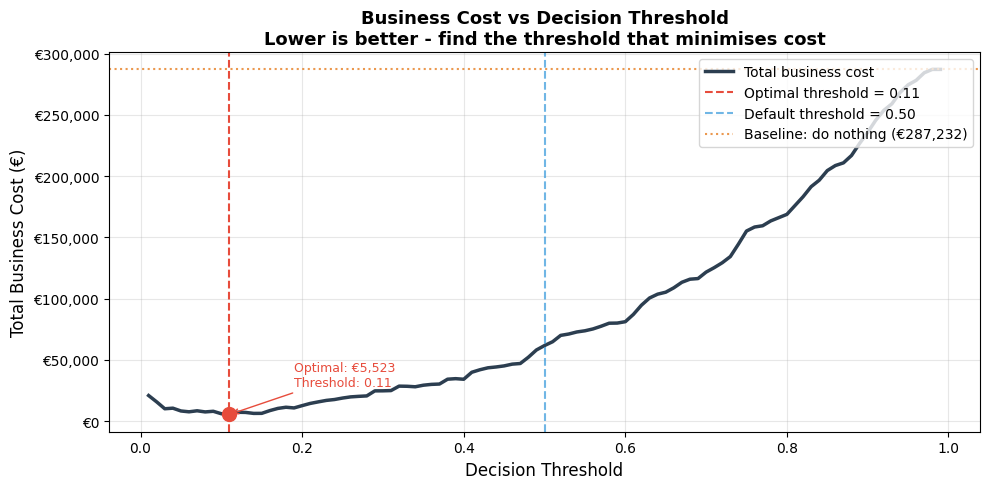

Threshold cost curve saved.


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, costs, color='#2c3e50', lw=2.5, label='Total business cost')

ax.axvline(opt_thresh, color='#e74c3c', linestyle='--', lw=1.5,
           label=f'Optimal threshold = {opt_thresh:.2f}')
ax.scatter([opt_thresh], [opt_cost], color='#e74c3c', s=100, zorder=5)

ax.axvline(0.5, color='#3498db', linestyle='--', lw=1.5, alpha=0.7,
           label='Default threshold = 0.50')

ax.axhline(baseline_do_nothing, color='#e67e22', linestyle=':', lw=1.5, alpha=0.8,
           label=f'Baseline: do nothing (€{baseline_do_nothing:,.0f})')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Total Business Cost (€)', fontsize=12)
ax.set_title('Business Cost vs Decision Threshold\n'
             'Lower is better - find the threshold that minimises cost', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

ax.annotate(f'Optimal: €{opt_cost:,.0f}\nThreshold: {opt_thresh:.2f}',
            xy=(opt_thresh, opt_cost),
            xytext=(opt_thresh + 0.08, opt_cost + (baseline_do_nothing * 0.08)),
            fontsize=9, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

plt.tight_layout()
plt.savefig('../reports/figures/threshold_cost_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Threshold cost curve saved.')

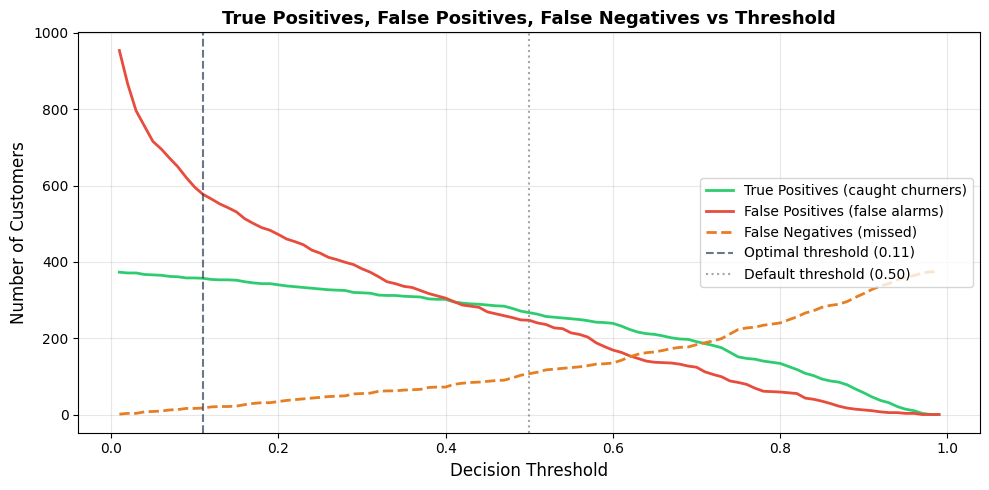

TP/FP trade-off plot saved.


In [21]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_tp = '#2ecc71'
color_fp = '#e74c3c'
color_fn = '#e67e22'

ax1.plot(thresholds, tps_list, color=color_tp, lw=2, label='True Positives (caught churners)')
ax1.plot(thresholds, fps_list, color=color_fp, lw=2, label='False Positives (false alarms)')
ax1.plot(thresholds, fns_list, color=color_fn, lw=2, linestyle='--', label='False Negatives (missed)')

ax1.axvline(opt_thresh, color='#2c3e50', linestyle='--', lw=1.5, alpha=0.7,
            label=f'Optimal threshold ({opt_thresh:.2f})')
ax1.axvline(0.5, color='grey', linestyle=':', lw=1.5, alpha=0.7,
            label='Default threshold (0.50)')

ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12)
ax1.set_title('True Positives, False Positives, False Negatives vs Threshold', fontsize=13, fontweight='bold')
ax1.legend(loc='center right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/threshold_tp_fp_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('TP/FP trade-off plot saved.')

In [22]:
saving_optimal = baseline_do_nothing - opt_cost
saving_default = baseline_do_nothing - model_cost_default
extra_from_tuning = saving_optimal - saving_default

saving_per_customer_optimal = saving_optimal / n_customers

customer_bases = [1_000, 10_000, 50_000, 100_000, 500_000]

print('=' * 65)
print('  ROI SUMMARY - Annual Cost Saving by Deploying XGBoost Model')
print('=' * 65)
print(f'  Cost assumptions:')
print(f'    Annual revenue per customer:  €{ANNUAL_REVENUE:,}')
print(f'    Retention offer cost:         €{OFFER_COST:,}')
print(f'    Retention success rate:       {RETENTION_RATE:.0%}')
print(f'    Optimal decision threshold:   {opt_thresh:.2f}')
print('-' * 65)
print(f'  On test set ({n_customers:,} customers):')
print(f'    Saving vs do-nothing (default threshold):  €{saving_default:>10,.0f}')
print(f'    Saving vs do-nothing (optimal threshold):  €{saving_optimal:>10,.0f}')
print(f'    Extra saving from threshold tuning:        €{extra_from_tuning:>10,.0f}')
print('-' * 65)
print(f'  Scaled savings (optimal threshold):')
for base in customer_bases:
    scaled = saving_per_customer_optimal * base
    print(f'    {base:>8,} customers → €{scaled:>12,.0f} / year')
print('=' * 65)

  ROI SUMMARY - Annual Cost Saving by Deploying XGBoost Model
  Cost assumptions:
    Annual revenue per customer:  €768
    Retention offer cost:         €80
    Retention success rate:       30%
    Optimal decision threshold:   0.11
-----------------------------------------------------------------
  On test set (1,407 customers):
    Saving vs do-nothing (default threshold):  €   225,453
    Saving vs do-nothing (optimal threshold):  €   281,709
    Extra saving from threshold tuning:        €    56,256
-----------------------------------------------------------------
  Scaled savings (optimal threshold):
       1,000 customers → €     200,219 / year
      10,000 customers → €   2,002,195 / year
      50,000 customers → €  10,010,974 / year
     100,000 customers → €  20,021,947 / year
     500,000 customers → € 100,109,737 / year


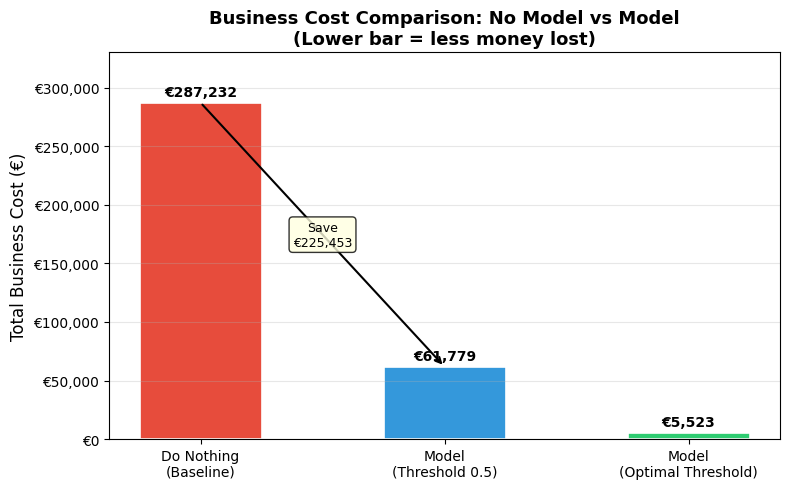

ROI comparison bar chart saved.


In [23]:
labels  = ['Do Nothing\n(Baseline)', 'Model\n(Threshold 0.5)', 'Model\n(Optimal Threshold)']
values  = [baseline_do_nothing, model_cost_default, opt_cost]
colours = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colours, width=0.5, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (baseline_do_nothing * 0.01),
            f'€{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.annotate('', xy=(1, model_cost_default), xytext=(0, baseline_do_nothing),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_ylabel('Total Business Cost (€)', fontsize=12)
ax.set_title('Business Cost Comparison: No Model vs Model\n'
             '(Lower bar = less money lost)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.set_ylim(0, baseline_do_nothing * 1.15)
ax.grid(True, axis='y', alpha=0.3)

mid_y = (baseline_do_nothing + model_cost_default) / 2
ax.text(0.5, mid_y, f'Save\n€{saving_default:,.0f}',
        ha='center', va='center', fontsize=9, color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/figures/roi_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROI comparison bar chart saved.')

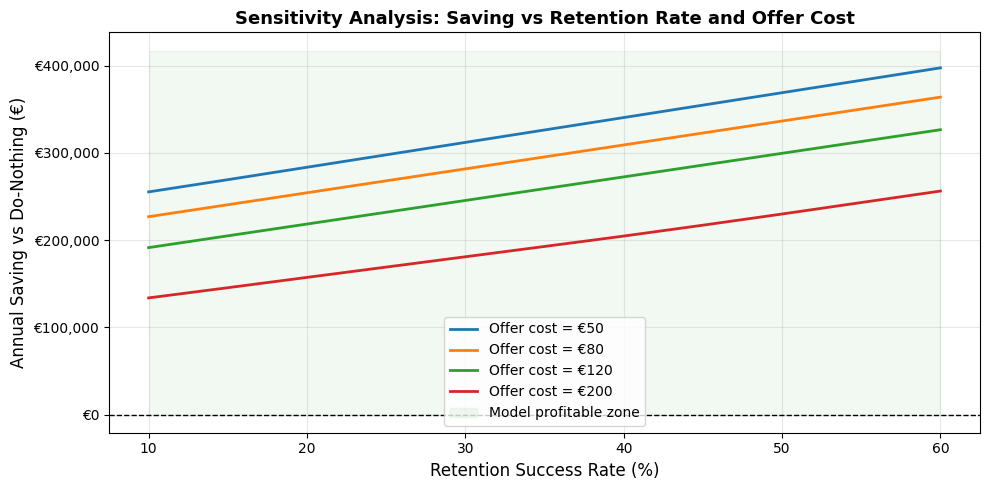

Sensitivity analysis saved.


In [ ]:
retention_rates = np.arange(0.10, 0.61, 0.05)   
offer_costs     = [50, 80, 120, 200]            

fig, ax = plt.subplots(figsize=(10, 5))

for offer in offer_costs:
    savings = []
    for ret_rate in retention_rates:
        c_tp = offer - (ANNUAL_REVENUE * ret_rate)
        c_fp = offer
        c_fn = ANNUAL_REVENUE

        thresh_costs = []
        for thresh in thresholds:
            y_pred_t = (y_prob >= thresh).astype(int)
            tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
            thresh_costs.append((tp_t * c_tp) + (fp_t * c_fp) + (fn_t * c_fn))
        best_cost = min(thresh_costs)

        base = int(n_churners) * ANNUAL_REVENUE
        savings.append(base - best_cost)

    ax.plot(retention_rates * 100, savings, lw=2, label=f'Offer cost = €{offer}')

ax.axhline(0, color='black', lw=1, linestyle='--')
ax.fill_between([10, 60], 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 200000,
                alpha=0.05, color='green', label='Model profitable zone')

ax.set_xlabel('Retention Success Rate (%)', fontsize=12)
ax.set_ylabel('Annual Saving vs Do-Nothing (€)', fontsize=12)
ax.set_title('Sensitivity Analysis: Saving vs Retention Rate and Offer Cost',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sensitivity analysis saved.')

In [25]:
import json

roi_params = {
    'monthly_charge':    MONTHLY_CHARGE,
    'annual_revenue':    ANNUAL_REVENUE,
    'offer_cost':        OFFER_COST,
    'retention_rate':    RETENTION_RATE,
    'optimal_threshold': float(opt_thresh),
    'n_test_customers':  int(n_customers),
    'saving_per_customer_optimal': float(saving_per_customer_optimal)
}

os.makedirs('../reports', exist_ok=True)
with open('../reports/roi_params.json', 'w') as f:
    json.dump(roi_params, f, indent=2)

print('ROI parameters saved to reports/roi_params.json')
print()
print(json.dumps(roi_params, indent=2))

ROI parameters saved to reports/roi_params.json

{
  "monthly_charge": 64,
  "annual_revenue": 768,
  "offer_cost": 80,
  "retention_rate": 0.3,
  "optimal_threshold": 0.11,
  "n_test_customers": 1407,
  "saving_per_customer_optimal": 200.21947405828
}
